### Testing visualizations

### Experiment with faded q block images

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="34aeVIOAX5XcJCubVAHR")
project = rf.workspace("nissha-medical").project("eagle-eyes-tbhgj")
version = project.version(23)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 133.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to eagle-eyes-23 in yolov8:: 100%|██████████| 6396/6396 [00:01<00:00, 6241.73it/s]


In [2]:
import os
import cv2
import numpy as np

In [4]:

dataset_root_path = dataset.location
print(f"Automatically Detected Dataset Path: {dataset_root_path}")
print(f"Type of object: {type(dataset)}")

# You can now use this variable to build the config_path
# Assuming the Roboflow download structure (YOLOv8)
# The data.yaml file is typically one level up from the 'train' folder.
config_path = os.path.join(dataset_root_path, 'data.yaml')
print(f"YOLOv8 Config Path: {config_path}")

Automatically Detected Dataset Path: /content/eagle-eyes-23
Type of object: <class 'roboflow.core.dataset.Dataset'>
YOLOv8 Config Path: /content/eagle-eyes-23/data.yaml


In [5]:
%pip install protobuf==3.20.3 tensorboard ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 43.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.


## Refactored pipeline


=== Loading Configuration ===
Class Map: {'backgroundclutter': 0, 'faded-qblock': 1, 'faded-smallqblock': 2, 'incorrect qblock': 3, 'qblock': 4, 'smallqblock': 5}
Correct block class id = 4
Incorrect block class id = 3
Ignored class ids = {0, 1, 2, 5}
Loading pre-trained YOLOv8n model...
Starting training with configuration: /content/eagle-eyes-23/data.yaml
Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/eagle-eyes-23/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0

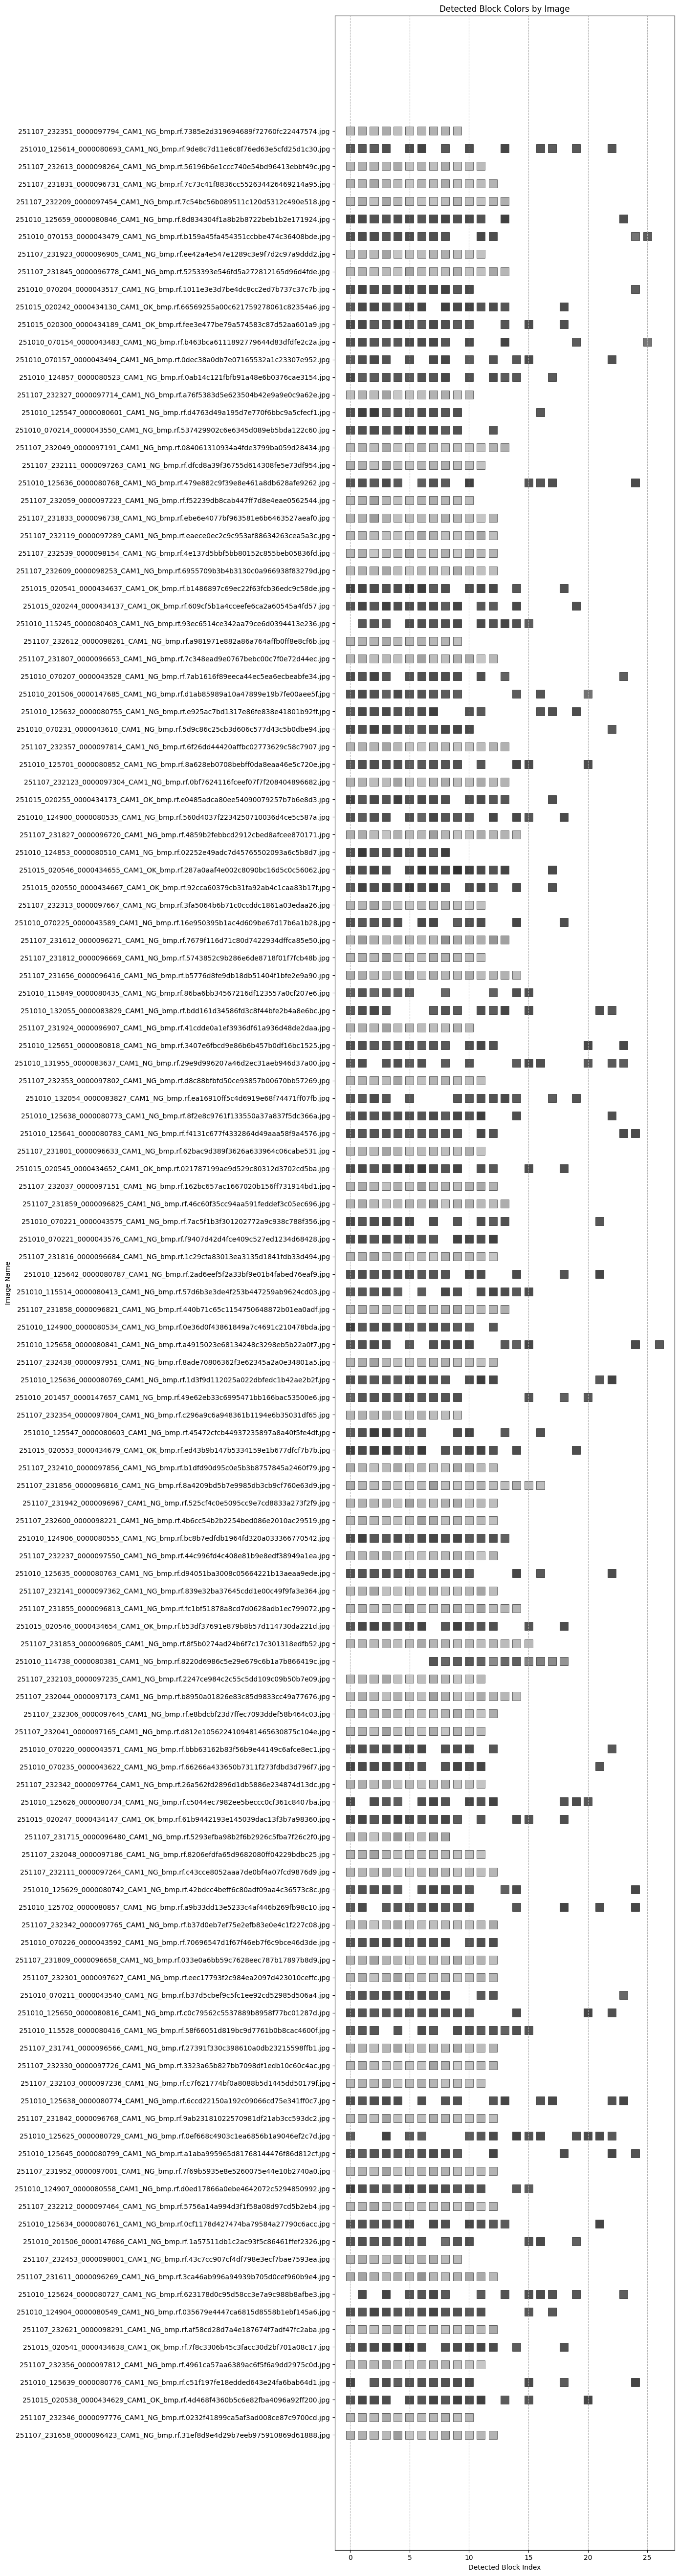

Saved scatter: results_visual/color_scatter.png


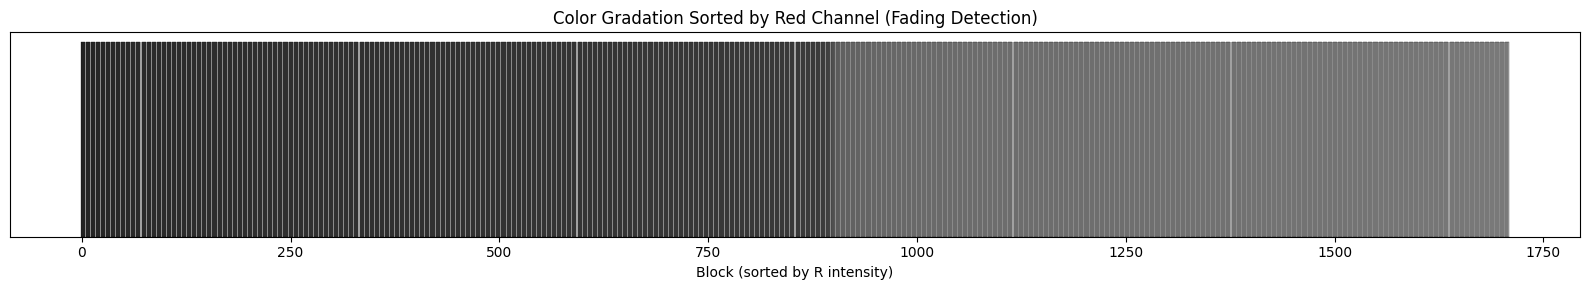

Saved gradation: results_visual/color_gradation.png


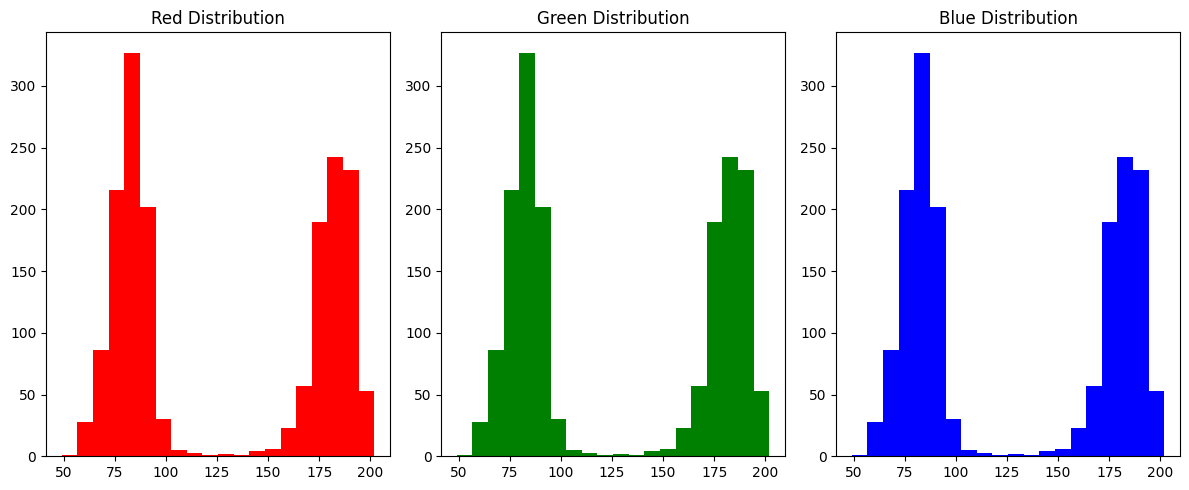

Saved RGB histograms: results_visual/rgb_histograms.png


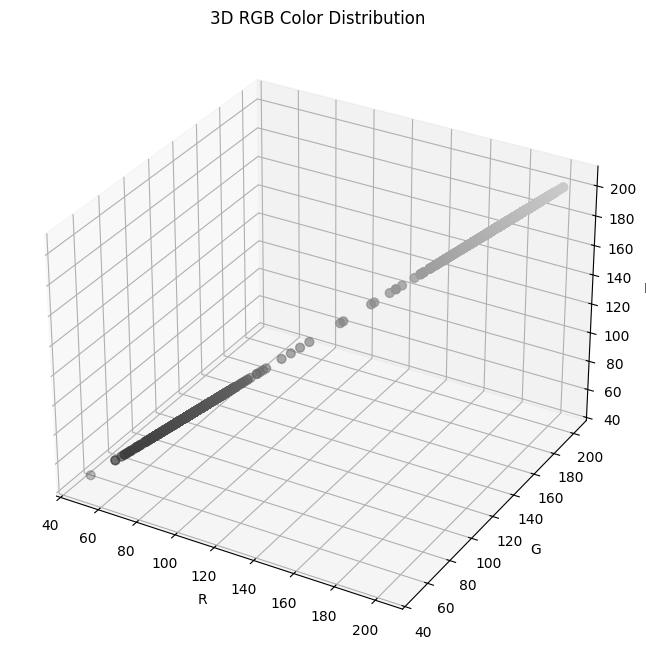

Saved 3D RGB scatter: results_visual/rgb_3d_scatter.png
Saved Δ-color metrics: results_visual/block_color_deltas.csv

Visualization & delta analysis complete.


In [10]:
import os
import cv2
import glob
import yaml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO

# -----------------------------
# CONFIGURATION
# -----------------------------
EXPECTED_QBLOCK_COUNT = 14

IGNORED_CLASSES = {
    "backgroundclutter",
    "smallqblock",
    "faded-qblock",
    "faded-smallqblock"
}

CORRECT_CLASS = "qblock"
INCORRECT_CLASS = "incorrect qblock"

CONFIDENCE_THRESHOLD = 0.5


# -------------------------------------------------------------
# Utility: Load YAML and return a dict mapping class names → IDs
# -------------------------------------------------------------
def load_class_map(config_path):
    with open(config_path, "r") as f:
        data = yaml.safe_load(f)

    names = data["names"]

    # list format
    if isinstance(names, list):
        return {name: idx for idx, name in enumerate(names)}

    # dict format
    elif isinstance(names, dict):
        return {v: k for k, v in names.items()}

    raise ValueError("Invalid 'names:' format in YAML.")


# --------------------------------------
# Extract average RGB color from a box
# --------------------------------------
def extract_roi_avg_color(img, box):
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
    roi = img[y1:y2, x1:x2]

    if roi.size == 0:
        return None

    avg_bgr = np.mean(roi, axis=(0, 1))
    r, g, b = avg_bgr[::-1].astype(int)
    hex_color = f"#{r:02x}{g:02x}{b:02x}"

    return (hex_color, r, g, b, (x1, y1, x2, y2))


# ----------------------------------------------------
# Determine GOOD/NOT GOOD classification per your rule
# ----------------------------------------------------
def classify_image(correct_count, incorrect_count):
    if correct_count == EXPECTED_QBLOCK_COUNT and incorrect_count == 0:
        return "GOOD"
    return "NOT_GOOD"


# -----------------------------
# MAIN PIPELINE ENTRY POINT
# -----------------------------
def run_pipeline():

    print("\n=== Loading Configuration ===")
    # config_path = "datasets/eagle-eyes-4/data.yaml"

    class_map = load_class_map(config_path)

    correct_id = class_map[CORRECT_CLASS]
    incorrect_id = class_map[INCORRECT_CLASS]

    ignored_ids = {class_map[name] for name in IGNORED_CLASSES if name in class_map}

    print("Class Map:", class_map)
    print("Correct block class id =", correct_id)
    print("Incorrect block class id =", incorrect_id)
    print("Ignored class ids =", ignored_ids)

    print("Loading pre-trained YOLOv8n model...")
    model = YOLO('yolov8n.pt')

    # ---------------------------------------------------
    # Train the Model
    # ---------------------------------------------------
    print(f"Starting training with configuration: {config_path}")
    results = model.train(
        data=config_path,
        epochs=10,
        imgsz=640,
        batch=-1,
        name='yolov8n_qblock_detector'
    )

    print("--- Training complete! ---")

    # --- 3. Display Final Validation Metrics ---
    print("\nFinal Validation Metrics from Training:")
    print(f"  mAP50-95: {results.box.map:.4f}")
    print(f"  Precision: {results.box.mp:.4f}")
    print(f"  Recall: {results.box.mr:.4f}")


    # ---------------------------------------------------
    # Load best trained model
    # ---------------------------------------------------
    print("\n=== Loading model ===")
    print("\nLoading the best model for inference...")
    results_directory = results.save_dir
    best_model_path = os.path.join(results_directory, 'weights/best.pt')
    if not os.path.exists(best_model_path):
        print(f"Error: Could not find best model at '{best_model_path}'.")
        return

    best_model = YOLO(best_model_path)
    print(f"Successfully loaded model from: {best_model_path}")

    model = best_model  # Change if needed


    # ---------------------------------------------------
    # Load test images
    # ---------------------------------------------------
    with open(config_path, "r") as f:
        data = yaml.safe_load(f)

    test_dir = os.path.join(os.path.dirname(config_path), "test", "images")

    test_images = []
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp"):
        test_images.extend(glob.glob(os.path.join(test_dir, ext)))

    print("Found test images:", len(test_images))


    # ---------------------------------------------------
    # Storage for all block color data
    # ---------------------------------------------------
    all_blocks = []
    correct_predictions = 0
    total_images = 0


    print("\n=== Running inference ===")
    results = model.predict(
        source=test_images,
        conf=CONFIDENCE_THRESHOLD,
        save=False,
        verbose=False
    )

    for img_path, result in zip(test_images, results):

        img_name = os.path.basename(img_path)
        img = cv2.imread(img_path)

        # Ground truth from filename
        if "_OK" in img_name.upper():
            ground_truth = "GOOD"
        elif "_NG" in img_name.upper():
            ground_truth = "NOT_GOOD"
        else:
            ground_truth = "UNKNOWN"

        correct_count = 0
        incorrect_count = 0

        # -----------------------------
        # PROCESS DETECTIONS
        # -----------------------------
        for i, box in enumerate(result.boxes):

            class_id = int(box.cls.cpu().item())

            # Skip ignored classes
            if class_id in ignored_ids:
                continue

            # Count correct / incorrect
            if class_id == correct_id:
                correct_count += 1
            elif class_id == incorrect_id:
                incorrect_count += 1

            # Extract color only for qblock / incorrect qblock
            if class_id in (correct_id, incorrect_id):
                extracted = extract_roi_avg_color(img, box)
                if extracted:
                    hex_color, r, g, b, coords = extracted

                    all_blocks.append({
                        "image_name": img_name,
                        "class_name": result.names[class_id],
                        "block_index": i,
                        "hex_color": hex_color,
                        "r": r, "g": g, "b": b,
                        "coords": coords
                    })

        # ------------------------------------
        # Apply QC rule
        # ------------------------------------
        model_pred = classify_image(correct_count, incorrect_count)

        if ground_truth != "UNKNOWN":
            total_images += 1
            if model_pred == ground_truth:
                correct_predictions += 1

        print(f"{img_name:<30} | Correct={correct_count:<2} Incorrect={incorrect_count:<2} | Pred={model_pred:<8} | GT={ground_truth}")


    # --------------------------------------------------------------
    # Summary Results
    # --------------------------------------------------------------
    print("\n=== QC Accuracy Results ===")
    if total_images > 0:
        acc = 100 * correct_predictions / total_images
        print(f"Total Scored Images: {total_images}")
        print(f"Correct Predictions: {correct_predictions}")
        print(f"Accuracy: {acc:.2f}%")
    else:
        print("No images with GT labels found.")

    # Save CSV of all block-level color data
    df = pd.DataFrame(all_blocks)
    df.to_csv("block_color_data.csv", index=False)
    print("\nSaved: block_color_data.csv")

    df = pd.read_csv("block_color_data.csv")
    results_dir = "results_visual"

    os.makedirs(results_dir, exist_ok=True)

    run_visualizations(df, results_dir)

# ============================================================
# 📌 1. COLOR SCATTER PLOT — ALL BLOCKS PER IMAGE
# ============================================================
def plot_color_scatter(df, results_dir):
    """
    Creates a scatter plot of all detected blocks (correct & incorrect)
    per image, showing their exact hex color.
    """
    if df.empty:
        print("No data for scatter plot.")
        return

    images = df['image_name'].unique()
    fig_height = max(6, len(images) * 0.4)

    plt.figure(figsize=(14, fig_height))

    plt.scatter(
        df['block_index'],
        df['image_name'],
        c=df['hex_color'],
        s=150,
        marker='s',
        edgecolors='black',
        linewidth=0.4
    )

    plt.xlabel("Detected Block Index")
    plt.ylabel("Image Name")
    plt.title("Detected Block Colors by Image")
    plt.grid(axis='x', linestyle='--')
    plt.tight_layout()

    outpath = os.path.join(results_dir, "color_scatter.png")
    plt.savefig(outpath)
    plt.show()
    plt.close()
    print("Saved scatter:", outpath)
# ============================================================
# 📌 2. COLOR GRADATION PLOT — SORTED BY RED CHANNEL
# ============================================================
def plot_color_gradation(df, results_dir):
    """
    Creates a horizontal bar of colors sorted by R channel.
    Shows overall brightness/fading across ALL blocks.
    """
    if df.empty:
        print("No data for gradation plot.")
        return

    df_sorted = df.sort_values(by='r', ascending=True).reset_index(drop=True)

    plt.figure(figsize=(16, 3))

    plt.bar(
        df_sorted.index,
        [1] * len(df_sorted),
        color=df_sorted['hex_color'],
        edgecolor='black',
        linewidth=0.2
    )

    plt.title("Color Gradation Sorted by Red Channel (Fading Detection)")
    plt.xlabel("Block (sorted by R intensity)")
    plt.yticks([])
    plt.tight_layout()

    outpath = os.path.join(results_dir, "color_gradation.png")
    plt.savefig(outpath)
    plt.show()
    plt.close()
    print("Saved gradation:", outpath)

# ============================================================
# 📌 3. RGB DIAGNOSTICS (Histograms + 3D RGB Cube)
# ============================================================
def plot_rgb_diagnostics(df, results_dir):

    if df.empty:
        print("No data for RGB diagnostics.")
        return

    # --- HISTOGRAMS ---
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.hist(df['r'], bins=20, color='red'); plt.title("Red Distribution")

    plt.subplot(1, 3, 2)
    plt.hist(df['g'], bins=20, color='green'); plt.title("Green Distribution")

    plt.subplot(1, 3, 3)
    plt.hist(df['b'], bins=20, color='blue'); plt.title("Blue Distribution")

    plt.tight_layout()
    outpath = os.path.join(results_dir, "rgb_histograms.png")
    plt.savefig(outpath)
    plt.show()
    plt.close()
    print("Saved RGB histograms:", outpath)

    # --- 3D RGB SCATTER ---
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(df['r'], df['g'], df['b'], c=df['hex_color'], s=40)
    ax.set_xlabel("R"); ax.set_ylabel("G"); ax.set_zlabel("B")
    ax.set_title("3D RGB Color Distribution")

    outpath = os.path.join(results_dir, "rgb_3d_scatter.png")
    plt.savefig(outpath)
    plt.show()
    plt.close()
    print("Saved 3D RGB scatter:", outpath)
# ============================================================
# 📌 4. COLOR DELTA ANALYSIS (Δ Intensity Deviation)
# ============================================================
def compute_color_deltas(df, results_dir):

    if df.empty:
        print("No data for delta analysis.")
        return df

    # --- Use only correct qblock (not incorrect qblock) for reference ---
    correct_df = df[df["class_name"] == "qblock"]

    if correct_df.empty:
        print("No correct qblocks for delta baseline.")
        return df

    ref_r = correct_df['r'].median()
    ref_g = correct_df['g'].median()
    ref_b = correct_df['b'].median()

    # Add Δ metric
    df['delta'] = np.sqrt(
        (df['r'] - ref_r)**2 +
        (df['g'] - ref_g)**2 +
        (df['b'] - ref_b)**2
    )

    outpath = os.path.join(results_dir, "block_color_deltas.csv")
    df.to_csv(outpath, index=False)
    print("Saved Δ-color metrics:", outpath)

    return df

# ============================================================
# 📌 5. COMBINED ENTRY POINT FOR VISUALIZATIONS
# ============================================================
def run_visualizations(df, results_dir):

    print("\n=== Running Visualization Suite ===")

    plot_color_scatter(df, results_dir)
    plot_color_gradation(df, results_dir)
    plot_rgb_diagnostics(df, results_dir)

    df_with_deltas = compute_color_deltas(df, results_dir)

    print("\nVisualization & delta analysis complete.")
    return df_with_deltas


if __name__ == "__main__":
    run_pipeline()



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
file_path = "block_color_deltas.csv"
def plot_delta_trend(file_path):
    """
    Loads historical delta data and plots the trend of the
    Approximate Total Color Difference (Delta E).

    Args:
        file_path (str): The path to the historical delta CSV file.
    """
    try:
        # Load the data
        df = pd.read_csv(file_path)
        
        # --- Data Cleaning and Preparation ---
        
        # 1. Ensure the date column is parsed as datetime objects
        #    NOTE: Replace 'date' with your actual timestamp column name (e.g., 'timestamp', 'batch_id').
        if 'date' in df.columns:
            time_column = 'date'
            df[time_column] = pd.to_datetime(df[time_column])
        else:
            # If no date/time column, use the row index as the time progression
            time_column = df.index
            print("Warning: No 'date' column found. Plotting against batch order (index).")

        # 2. Ensure Delta E is numeric
        #    NOTE: Replace 'delta_e' with your actual Delta E column name if different.
        df['delta_e'] = pd.to_numeric(df['delta_e'], errors='coerce')
        df.dropna(subset=['delta_e'], inplace=True)

        # 3. Sort by time/index
        df.sort_values(by=time_column, inplace=True)
        
        # --- Visualization ---

        plt.figure(figsize=(12, 6))
        
        # Plot the Delta E trend over time
        plt.plot(df[time_column], df['delta_e'], marker='o', linestyle='-', color='firebrick', linewidth=2, label='Approximate $\Delta E$')

        # Calculate and plot the average Delta E across all historical batches
        mean_delta_e = df['delta_e'].mean()
        plt.axhline(mean_delta_e, color='gray', linestyle='--', linewidth=1.5, label=f'Historical Average (M = {mean_delta_e:.2f})')
        
        # Determine the alert threshold (e.g., 10% above the historical average)
        alert_threshold = mean_delta_e * 1.10
        plt.axhline(alert_threshold, color='red', linestyle=':', linewidth=1.5, label=f'Prediction Alert Threshold (+10% = {alert_threshold:.2f})')

        plt.title('Predictive QC: Total Color Difference ($\Delta E$) Trend Over Time')
        plt.xlabel(time_column.title() if isinstance(time_column, str) else 'Batch Order')
        plt.ylabel('Total Color Difference ($\Delta E$ Value)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('delta_trend_visualization.png')
        plt.show()

    except FileNotFoundError:
        print(f"Error: The file at path '{file_path}' was not found. Please verify the file path.")
    except Exception as e:
        print(f"An unexpected error occurred during processing: {e}")

# --- EXAMPLE USAGE ---
# 1. Replace 'delta_history.csv' with the actual file name.
# 2. Ensure your CSV has a column that can be parsed as a date/time or used for ordering.
# plot_delta_trend('delta_history.csv')

<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:51: SyntaxWarning: invalid escape sequence '\D'
<>:53: SyntaxWarning: invalid escape sequence '\D'
<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:51: SyntaxWarning: invalid escape sequence '\D'
<>:53: SyntaxWarning: invalid escape sequence '\D'
/var/folders/9_/cv27drrj3759y9yrmhdcbnv40000gn/T/ipykernel_96147/933419294.py:41: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(df[time_column], df['delta_e'], marker='o', linestyle='-', color='firebrick', linewidth=2, label='Approximate $\Delta E$')
/var/folders/9_/cv27drrj3759y9yrmhdcbnv40000gn/T/ipykernel_96147/933419294.py:51: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Predictive QC: Total Color Difference ($\Delta E$) Trend Over Time')
/var/folders/9_/cv27drrj3759y9yrmhdcbnv40000gn/T/ipykernel_96147/933419294.py:53: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Total Color Difference ($\Delta E$ Value)')

A module that was compiled using NumPy 1.

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv("block_color_deltas.csv")   # change path if needed

# Plot the delta value trend
plt.figure(figsize=(12,5))
plt.plot(df['delta'])
plt.xlabel("Index")
plt.ylabel("Delta Value")
plt.title("Trend Variation of Delta Values")
plt.tight_layout()
plt.show()


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject